In [1]:
import torch
from torch.utils.data import DataLoader, random_split, TensorDataset
from d2l import torch as d2l
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import matplotlib.pyplot as plt
import numpy as np
import time
import random

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MTFraEng(d2l.DataModule):
    def _download(self):
        d2l.extract(d2l.download(
            d2l.DATA_URL + 'fra-eng.zip', self.root,
            '94646ad1522d915e7b0f9296181140edcf86a4f5'))
        with open(self.root + '/fra-eng/fra.txt', encoding='utf-8') as f:
            return f.read()

raw_text = MTFraEng()._download()

def tokenize_simple(text):
    return text.lower().strip().split()

def custom_preprocess(text):
    lines = text.strip().split('\n')
    pairs = [line.split('\t') for line in lines if '\t' in line]
    src = [tokenize_simple(s) for s, _ in pairs]
    tgt = [tokenize_simple(t) for _, t in pairs]
    return src, tgt

src_sentences, tgt_sentences = custom_preprocess(raw_text)
src_sentences = src_sentences[:3000]
tgt_sentences = tgt_sentences[:3000]

reserved_tokens = ['<pad>', '<bos>', '<eos>', '<unk>']
src_vocab = d2l.Vocab(src_sentences, min_freq=1, reserved_tokens=reserved_tokens)
tgt_vocab = d2l.Vocab(tgt_sentences, min_freq=1, reserved_tokens=reserved_tokens)

pad_idx = tgt_vocab['<pad>']
bos_idx = tgt_vocab['<bos>']
eos_idx = tgt_vocab['<eos>']

def build_tensor(lines, vocab, num_steps, bos=False, eos=False):
    out = []
    for line in lines:
        tokens = ([vocab['<bos>']] if bos else []) + \
                 [vocab[token] if token in vocab.token_to_idx else vocab['<unk>'] for token in line] + \
                 ([vocab['<eos>']] if eos else [])
        if len(tokens) > num_steps:
            tokens = tokens[:num_steps]
        else:
            tokens += [vocab['<pad>']] * (num_steps - len(tokens))
        out.append(torch.tensor(tokens))
    return torch.stack(out)

num_steps = 20
src_tensor = build_tensor(src_sentences, src_vocab, num_steps, eos=True)
tgt_tensor = build_tensor(tgt_sentences, tgt_vocab, num_steps, bos=True, eos=True)

full_dataset = TensorDataset(src_tensor, tgt_tensor)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

#function to generate predictions batch wise
test_pairs = list(zip(
    [" ".join(s) for s in src_sentences[:10]],
    [" ".join(t) for t in tgt_sentences[:10]]
))

def batch_predict(model, src_sentences, src_vocab, tgt_vocab, max_len=20):
    model.eval()
    predictions = []

    with torch.no_grad():
        for sentence in src_sentences:
            tokens = sentence.lower().strip().split()
            token_ids = [src_vocab[token] if token in src_vocab.token_to_idx else src_vocab['<unk>'] for token in tokens]
            token_ids.append(src_vocab['<eos>'])

            src_tensor = torch.tensor(token_ids, dtype=torch.long, device=device).unsqueeze(1)
            encoder_outputs, hidden = model.encoder(src_tensor)

            input_token = torch.tensor([bos_idx], device=device)
            output_tokens = []

            for _ in range(max_len):
                output, hidden, _ = model.decoder(input_token, hidden, encoder_outputs)
                top1 = output.argmax(1)
                if top1.item() == eos_idx:
                    break
                output_tokens.append(tgt_vocab.idx_to_token[top1.item()])
                input_token = top1

            predictions.append(" ".join(output_tokens))
    
    return predictions


def tokenizer_src(sentence):
    tokens = sentence.lower().strip().split()
    token_ids = [src_vocab[token] if token in src_vocab.token_to_idx else src_vocab['<unk>'] for token in tokens]
    token_ids.append(src_vocab['<eos>'])
    return torch.tensor(token_ids, dtype=torch.long, device=device).unsqueeze(1)



In [3]:
class BasicAttention(nn.Module):   #Bahdanau Attention
    def __init__(self, encoder_hidden_size, decoder_hidden_size, attention_size):
        super().__init__()
        self.W1 = nn.Linear(encoder_hidden_size, attention_size)
        self.W2 = nn.Linear(decoder_hidden_size, attention_size)
        self.v = nn.Linear(attention_size, 1)

    def forward(self, encoder_outputs, decoder_hidden):
        decoder_hidden = decoder_hidden.unsqueeze(1)  # (batch_size, 1, dec_hidden)
        scores = self.v(torch.tanh(self.W1(encoder_outputs) + self.W2(decoder_hidden)))
        attention_weights = F.softmax(scores, dim=1)  # (batch, seq_len, 1)
        context_vector = torch.sum(attention_weights * encoder_outputs, dim=1)
        return context_vector, attention_weights.squeeze(-1)

class AttentiveDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size, encoder_hidden_size, decoder_hidden_size, attention_size, n_layers=1, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.attention = BasicAttention(encoder_hidden_size, decoder_hidden_size, attention_size)
        self.rnn = nn.GRU(embed_size + encoder_hidden_size, decoder_hidden_size, num_layers=n_layers, dropout=dropout if n_layers > 1 else 0)
        self.fc = nn.Linear(decoder_hidden_size, vocab_size)

    def forward(self, input_token, hidden_state, encoder_outputs):
        embedded = self.embedding(input_token).unsqueeze(0)
        context_vector, attention_weights = self.attention(encoder_outputs, hidden_state[-1])
        rnn_input = torch.cat((embedded, context_vector.unsqueeze(0)), dim=2)
        output, hidden = self.rnn(rnn_input, hidden_state)
        output = self.fc(output.squeeze(0))
        return output, hidden, attention_weights

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, n_layers=1, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, hidden_size, num_layers=n_layers, dropout=dropout if n_layers > 1 else 0)

    def forward(self, input_seq):
        embedded = self.embedding(input_seq)
        outputs, hidden = self.rnn(embedded)
        return outputs.transpose(0, 1), hidden

class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        tgt_len, batch_size = tgt.shape  # ✅ Fix: sequence-first shape
        vocab_size = self.decoder.fc.out_features
        outputs = torch.zeros(tgt_len, batch_size, vocab_size).to(src.device)
        attentions = []
    
        encoder_outputs, hidden = self.encoder(src)
        input_token = tgt[0, :]
    
        for t in range(1, tgt_len):
            output, hidden, attn_weights = self.decoder(input_token, hidden, encoder_outputs)
            outputs[t, :, :] = output
            attentions.append(attn_weights)
            teacher_force = random.random() < teacher_forcing_ratio
            input_token = tgt[t] if teacher_force else output.argmax(1)
    
        return outputs, attentions



In [4]:
def train_with_logging(model, train_loader, val_loader, optimizer, criterion, num_epochs):
    train_losses, val_losses = [], []
    for epoch in range(num_epochs):
        model.train()
        total_loss, total_tokens = 0, 0
        for src, tgt in train_loader:
            src, tgt = src.to(device), tgt.to(device)
            optimizer.zero_grad()
            output, _ = model(src.T, tgt.T)  # (tgt_len, batch, vocab)
            loss = criterion(output[1:].reshape(-1, output.shape[-1]), tgt.T[1:].reshape(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * tgt.T[1:].numel()
            total_tokens += tgt.T[1:].numel()
        avg_train_loss = total_loss / total_tokens
        train_losses.append(avg_train_loss)
        print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f} | Perplexity: {np.exp(avg_train_loss):.2f}")
        if val_loader:
            model.eval()
            val_loss, val_tokens = 0, 0
            with torch.no_grad():
                for src, tgt in val_loader:
                    src, tgt = src.to(device), tgt.to(device)
                    output, _ = model(src.T, tgt.T, teacher_forcing_ratio=0)
                    loss = criterion(output[1:].reshape(-1, output.shape[-1]), tgt.T[1:].reshape(-1))
                    val_loss += loss.item() * tgt.T[1:].numel()
                    val_tokens += tgt.T[1:].numel()
            avg_val_loss = val_loss / val_tokens
            val_losses.append(avg_val_loss)
            print(f"Epoch {epoch+1} - Val Loss: {avg_val_loss:.4f} | Val Perplexity: {np.exp(avg_val_loss):.2f}")

    return train_losses, val_losses
    
def predict(model, src_tensor, max_len=20):
    if src_tensor.dim() == 1:
        src_tensor = src_tensor.unsqueeze(1)

    model.eval()
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)
        input_token = torch.tensor([bos_idx], device=src_tensor.device)
        outputs = []
        attentions = []
        for _ in range(max_len):
            output, hidden, attn_weights = model.decoder(input_token, hidden, encoder_outputs)
            predicted = output.argmax(1)
            outputs.append(predicted.item())
            attentions.append(attn_weights.detach().cpu())

            if predicted.item() == eos_idx:
                break
            input_token = predicted

        return outputs, attentions



In [5]:
def compute_bleu(pred_indices, tgt_sentence, tgt_vocab):
    pred_tokens = [tgt_vocab.idx_to_token[idx] for idx in pred_indices if idx < len(tgt_vocab)]
    ref_tokens = tgt_sentence.strip().lower().split()

    smoothing = SmoothingFunction().method1
    return sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoothing)


def evaluate_bleu(model, test_pairs, tgt_vocab, max_len=20):
    total_score = 0
    for src_text, tgt_text in test_pairs:
        src_tensor = tokenizer_src(src_text)
        pred_indices, _ = predict(model, src_tensor, max_len=max_len)
        score = compute_bleu(pred_indices, tgt_text, tgt_vocab)
        total_score += score
    return total_score / len(test_pairs)

def plot_attention(attn_weights, input_tokens, output_tokens):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(attn_weights[:len(output_tokens), :len(input_tokens)].numpy(),
                xticklabels=input_tokens, yticklabels=output_tokens,
                cmap='viridis', ax=ax)
    plt.xlabel("Input Tokens")
    plt.ylabel("Predicted Tokens")
    plt.title("Basic Attention")
    plt.show()

def show_sample_prediction(model, src_text, tgt_text, src_vocab, tgt_vocab):
    src_tokens = src_text.lower().strip().split()
    input_tensor = torch.tensor(
        [src_vocab[token] for token in src_tokens if token in src_vocab] + [src_vocab['<eos>']],
        dtype=torch.long, device=device
    ).unsqueeze(1)

    pred_indices, attn_weights = predict(model, input_tensor)
    pred_tokens = [tgt_vocab.idx_to_token[idx] for idx in pred_indices]

    print(f"\n Source: {src_text}")
    print(f" Predicted: {' '.join(pred_tokens)}")
    print(f" Target: {tgt_text}")

    plot_attention(attn_weights, src_tokens, pred_tokens)



Config 1: {'emb_dim': 64, 'hid_dim': 128, 'n_layers': 1, 'dropout': 0.1, 'lr': 0.005}

Training model for Config 1...
Epoch 1 - Train Loss: 4.8239 | Perplexity: 124.44
Epoch 1 - Val Loss: 4.3879 | Val Perplexity: 80.47
Epoch 2 - Train Loss: 3.6563 | Perplexity: 38.72
Epoch 2 - Val Loss: 4.1771 | Val Perplexity: 65.17
Epoch 3 - Train Loss: 2.8807 | Perplexity: 17.83
Epoch 3 - Val Loss: 4.1067 | Val Perplexity: 60.75
Epoch 4 - Train Loss: 2.3270 | Perplexity: 10.25
Epoch 4 - Val Loss: 4.1078 | Val Perplexity: 60.81
Epoch 5 - Train Loss: 1.9005 | Perplexity: 6.69
Epoch 5 - Val Loss: 4.3173 | Val Perplexity: 74.98
Epoch 6 - Train Loss: 1.6720 | Perplexity: 5.32
Epoch 6 - Val Loss: 4.3504 | Val Perplexity: 77.51
Epoch 7 - Train Loss: 1.4663 | Perplexity: 4.33
Epoch 7 - Val Loss: 4.5080 | Val Perplexity: 90.74
Epoch 8 - Train Loss: 1.3786 | Perplexity: 3.97
Epoch 8 - Val Loss: 4.5431 | Val Perplexity: 93.98
Epoch 9 - Train Loss: 1.2987 | Perplexity: 3.66
Epoch 9 - Val Loss: 4.6713 | Val Per

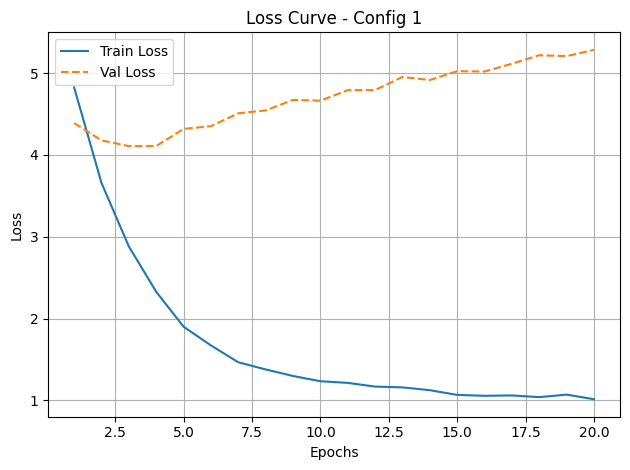

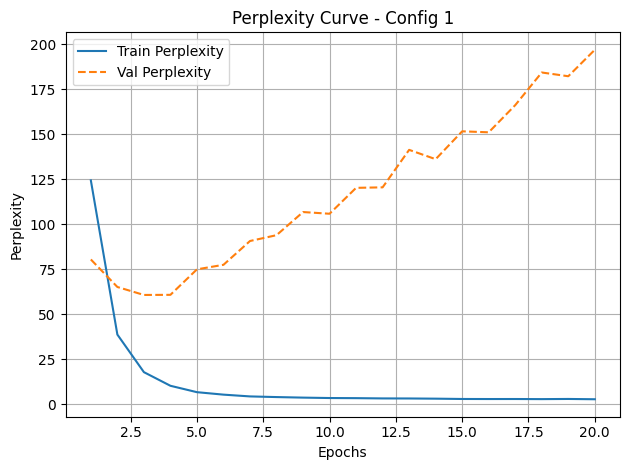

Source: go.
Predicted: allons-y !
Target: va !

Source: hi.
Predicted: salut !
Target: salut !

Source: run!
Predicted: cours !
Target: cours !

Source: run!
Predicted: cours !
Target: courez !

Source: who?
Predicted: qui ?
Target: qui ?

Source: wow!
Predicted: ça alors !
Target: ça alors !

Source: fire!
Predicted: au joue !
Target: au feu !

Source: help!
Predicted: à l'aide !
Target: à l'aide !

Source: jump.
Predicted: saute.
Target: saute.

Source: stop!
Predicted: stop !
Target: ça suffit !


Config 2: {'emb_dim': 128, 'hid_dim': 256, 'n_layers': 1, 'dropout': 0.1, 'lr': 0.001}

Training model for Config 2...
Epoch 1 - Train Loss: 4.5782 | Perplexity: 97.34
Epoch 1 - Val Loss: 4.0784 | Val Perplexity: 59.05
Epoch 2 - Train Loss: 3.5071 | Perplexity: 33.35
Epoch 2 - Val Loss: 3.8695 | Val Perplexity: 47.92
Epoch 3 - Train Loss: 2.8014 | Perplexity: 16.47
Epoch 3 - Val Loss: 3.7994 | Val Perplexity: 44.68
Epoch 4 - Train Loss: 2.2270 | Perplexity: 9.27
Epoch 4 - Val Loss: 3.6908 

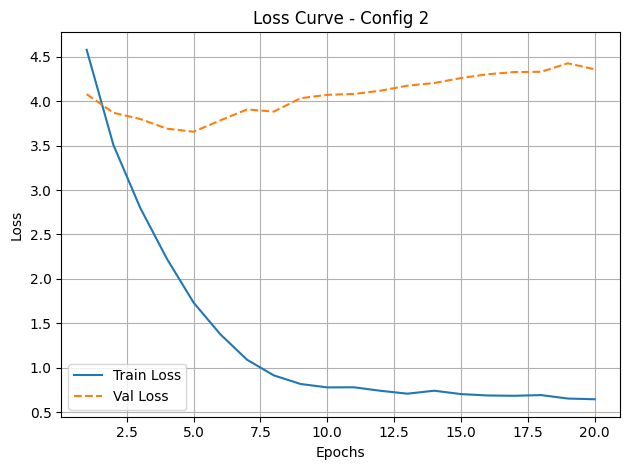

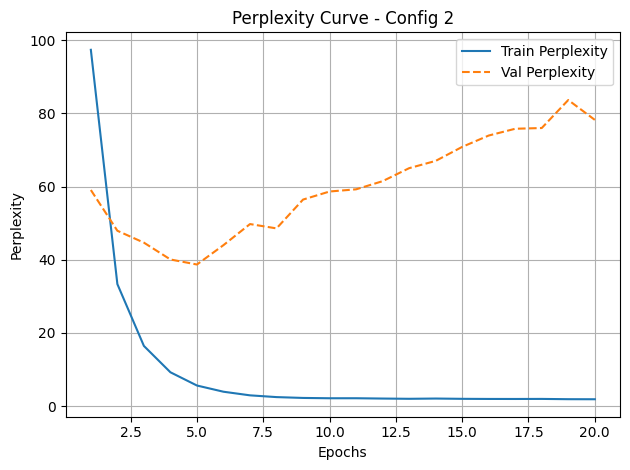

Source: go.
Predicted: va !
Target: va !

Source: hi.
Predicted: salut !
Target: salut !

Source: run!
Predicted: cours !
Target: cours !

Source: run!
Predicted: cours !
Target: courez !

Source: who?
Predicted: qui ?
Target: qui ?

Source: wow!
Predicted: ça alors !
Target: ça alors !

Source: fire!
Predicted: au feu !
Target: au feu !

Source: help!
Predicted: à l'aide l'aide !
Target: à l'aide !

Source: jump.
Predicted: saute.
Target: saute.

Source: stop!
Predicted: stop !
Target: ça suffit !


Config 3: {'emb_dim': 256, 'hid_dim': 512, 'n_layers': 1, 'dropout': 0.2, 'lr': 0.0005}

Training model for Config 3...
Epoch 1 - Train Loss: 4.4967 | Perplexity: 89.72
Epoch 1 - Val Loss: 3.9608 | Val Perplexity: 52.50
Epoch 2 - Train Loss: 3.3245 | Perplexity: 27.78
Epoch 2 - Val Loss: 3.7563 | Val Perplexity: 42.79
Epoch 3 - Train Loss: 2.5728 | Perplexity: 13.10
Epoch 3 - Val Loss: 3.6214 | Val Perplexity: 37.39
Epoch 4 - Train Loss: 1.9604 | Perplexity: 7.10
Epoch 4 - Val Loss: 3.6276

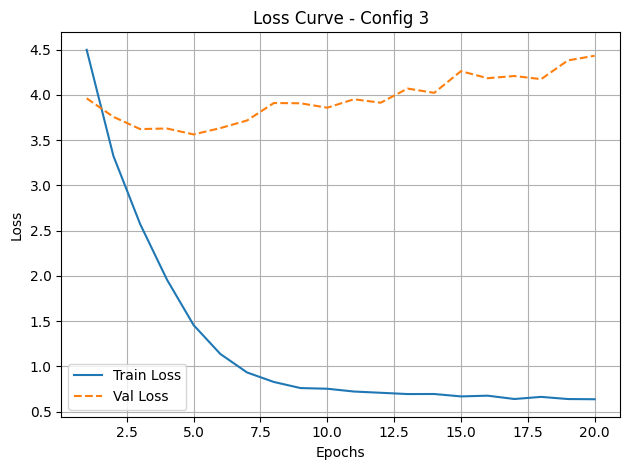

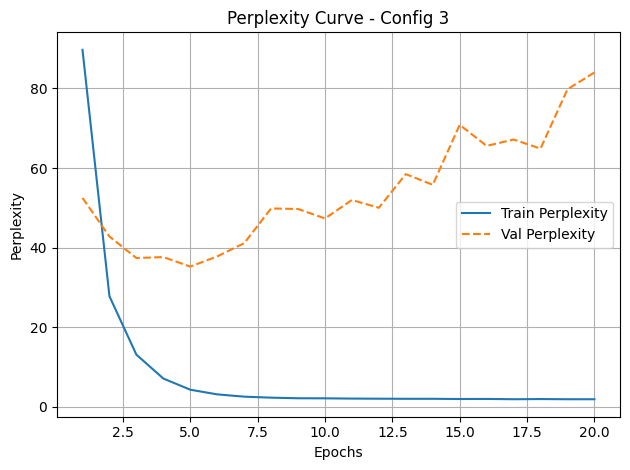

Source: go.
Predicted: va !
Target: va !

Source: hi.
Predicted: salut !
Target: salut !

Source: run!
Predicted: cours !
Target: cours !

Source: run!
Predicted: cours !
Target: courez !

Source: who?
Predicted: qui ?
Target: qui ?

Source: wow!
Predicted: ça alors !
Target: ça alors !

Source: fire!
Predicted: au feu !
Target: au feu !

Source: help!
Predicted: à l'aide !
Target: à l'aide !

Source: jump.
Predicted: saute.
Target: saute.

Source: stop!
Predicted: ça !
Target: ça suffit !


Config 4: {'emb_dim': 512, 'hid_dim': 1024, 'n_layers': 2, 'dropout': 0.3, 'lr': 0.0001}

Training model for Config 4...
Epoch 1 - Train Loss: 4.7417 | Perplexity: 114.63
Epoch 1 - Val Loss: 4.3128 | Val Perplexity: 74.65
Epoch 2 - Train Loss: 3.9056 | Perplexity: 49.68
Epoch 2 - Val Loss: 4.1904 | Val Perplexity: 66.05
Epoch 3 - Train Loss: 3.4357 | Perplexity: 31.05
Epoch 3 - Val Loss: 3.9948 | Val Perplexity: 54.32
Epoch 4 - Train Loss: 3.0619 | Perplexity: 21.37
Epoch 4 - Val Loss: 3.9636 | Val

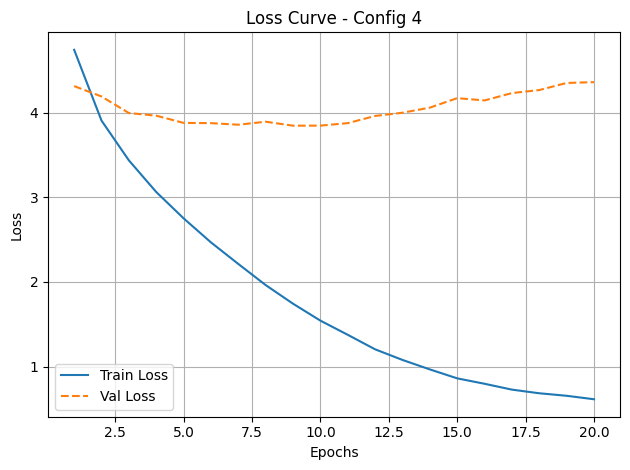

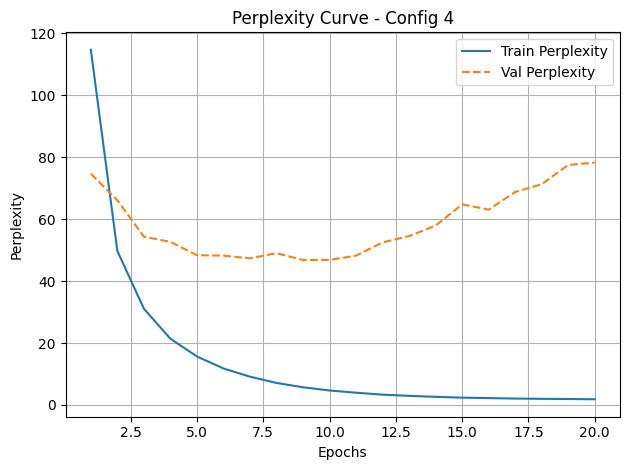

Source: go.
Predicted: va !
Target: va !

Source: hi.
Predicted: salut !
Target: salut !

Source: run!
Predicted: pas !
Target: cours !

Source: run!
Predicted: pas !
Target: courez !

Source: who?
Predicted: qui ?
Target: qui ?

Source: wow!
Predicted: couillon couillon armé. armé. armé. armé. armé. armé. armé. couillon armé. armé. couillon armé. couillon armé. couillon armé. couillon couillon
Target: ça alors !

Source: fire!
Predicted: au feu !
Target: au feu !

Source: help!
Predicted: est fou. fou. vivant. vivant. vivant. vivant. vivant. vivant. vivant. vivant. vivant. vivant. vivant. vivant. vivant. vivant. vivant. vivant. vivant.
Target: à l'aide !

Source: jump.
Predicted: le là.
Target: saute.

Source: stop!
Predicted: pas sûr.
Target: ça suffit !



In [6]:
hyperparams = [
    {"emb_dim": 64, "hid_dim": 128, "n_layers": 1, "dropout": 0.1, "lr": 0.005},
    {"emb_dim": 128, "hid_dim": 256, "n_layers": 1, "dropout": 0.1, "lr": 0.001},
    {"emb_dim": 256, "hid_dim": 512, "n_layers": 1, "dropout": 0.2, "lr": 0.0005},
    {"emb_dim": 512, "hid_dim": 1024, "n_layers": 2, "dropout": 0.3, "lr": 0.0001}
]

results = []

for i, h in enumerate(hyperparams):
    print(f"\nConfig {i+1}: {h}")

    encoder = Encoder(len(src_vocab), h["emb_dim"], h["hid_dim"],
                      n_layers=h["n_layers"], dropout=h["dropout"])
    
    decoder = AttentiveDecoder(len(tgt_vocab), h["emb_dim"], h["hid_dim"],
                               h["hid_dim"], attention_size=128,
                               n_layers=h["n_layers"], dropout=h["dropout"])

    model = Seq2SeqWithAttention(encoder, decoder).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=h["lr"])
    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

    print(f"\nTraining model for Config {i+1}...")
    train_losses, val_losses = train_with_logging(model, train_loader, val_loader, optimizer, criterion, num_epochs=20)

    print(f"\nEvaluating BLEU score...")
    start = time.time()
    bleu_score = evaluate_bleu(model, test_pairs, tgt_vocab, max_len=20)
    elapsed = time.time() - start
    print(f"Config {i+1} BLEU Score: {bleu_score:.4f} | Time taken: {elapsed:.2f} seconds")

#plot loss
    epochs = list(range(1, len(train_losses) + 1))
    plt.figure()
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss', linestyle='--')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Loss Curve - Config {i+1}')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

#plot perplexity
    train_ppl = [np.exp(l) for l in train_losses]
    val_ppl = [np.exp(l) for l in val_losses]
    plt.figure()
    plt.plot(epochs, train_ppl, label='Train Perplexity')
    plt.plot(epochs, val_ppl, label='Val Perplexity', linestyle='--')
    plt.xlabel('Epochs')
    plt.ylabel('Perplexity')
    plt.title(f'Perplexity Curve - Config {i+1}')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    results.append({
        "config": h,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "bleu": bleu_score,
        "time": elapsed
    })

    preds = batch_predict(model, [pair[0] for pair in test_pairs], src_vocab, tgt_vocab)
    for i, (src, tgt) in enumerate(test_pairs):
        print(f"Source: {src}")
        print(f"Predicted: {preds[i]}")
        print(f"Target: {tgt}\n")



Example 1
Source:    go.
Predicted: va !
Target:    va !


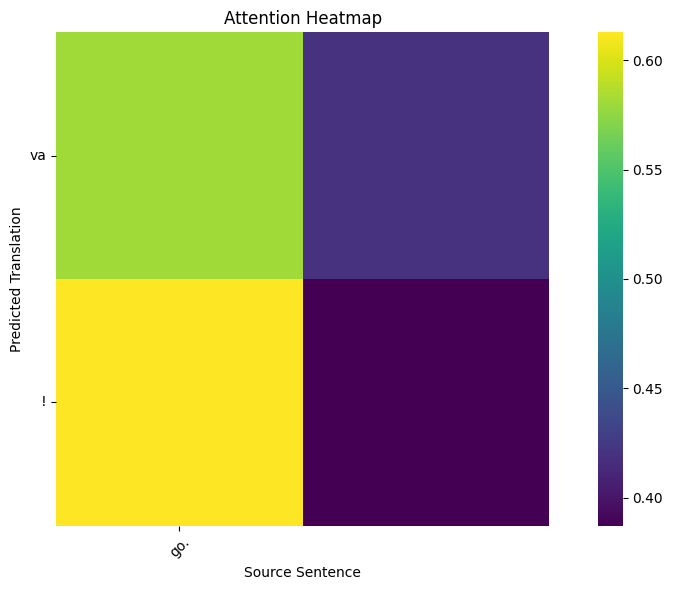


Example 2
Source:    hi.
Predicted: salut !
Target:    salut !


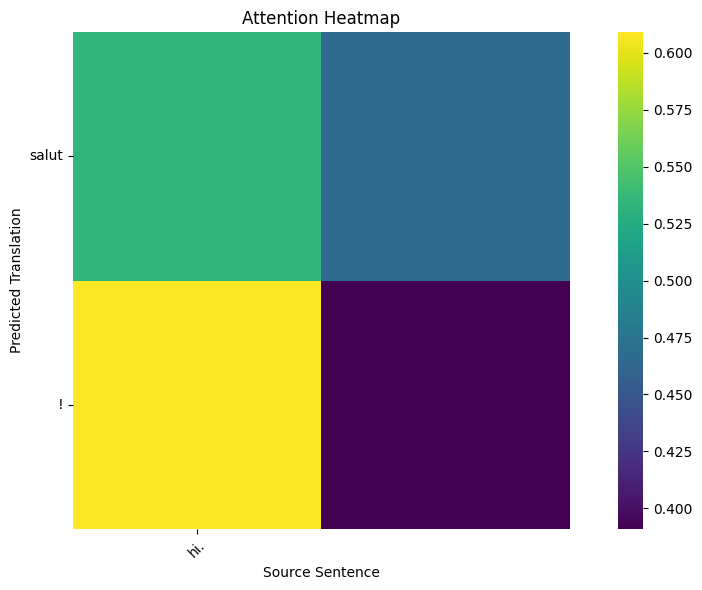


Example 3
Source:    run!
Predicted: pas !
Target:    cours !


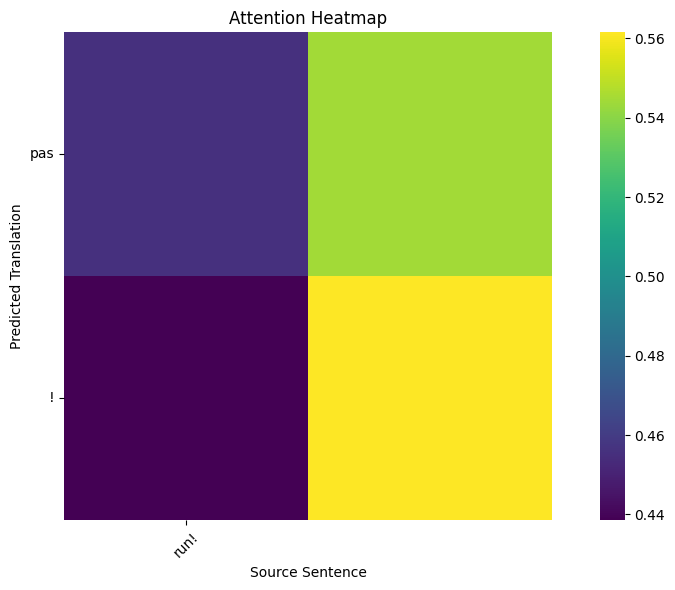


Example 4
Source:    run!
Predicted: pas !
Target:    courez !


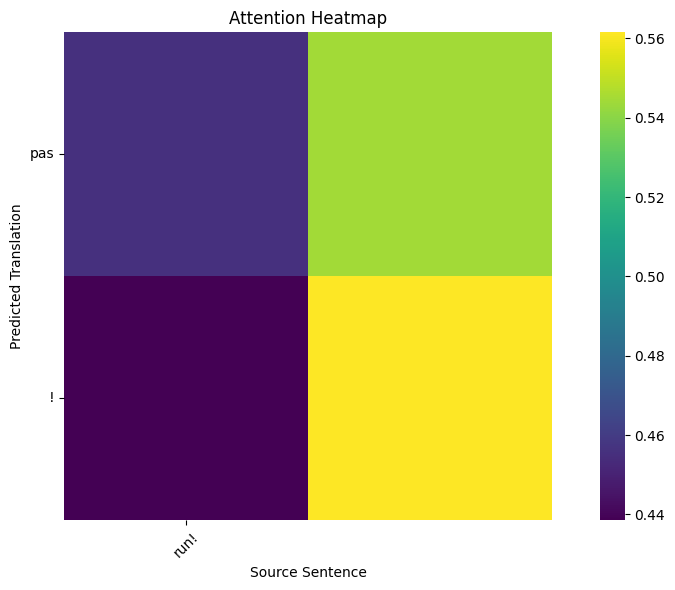


Example 5
Source:    who?
Predicted: qui ?
Target:    qui ?


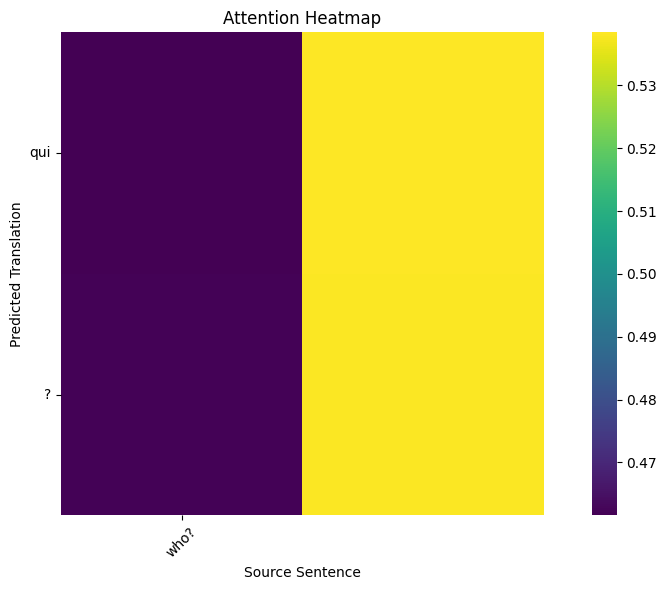

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

def predict_with_attention(model, src_sentence, src_vocab, tgt_vocab, max_len=20):
    model.eval()
    with torch.no_grad():
        tokens = src_sentence.lower().strip().split()
        token_ids = [src_vocab[token] if token in src_vocab.token_to_idx else src_vocab['<unk>'] for token in tokens]
        token_ids.append(src_vocab['<eos>'])
        src_tensor = torch.tensor(token_ids, dtype=torch.long, device=device).unsqueeze(1)
        encoder_outputs, hidden = model.encoder(src_tensor)
        input_token = torch.tensor([bos_idx], device=device)
        predicted_tokens = []
        attention_weights = []
        for _ in range(max_len):
            output, hidden, attn_weight = model.decoder(input_token, hidden, encoder_outputs)
            top1 = output.argmax(1)
            if top1.item() == eos_idx:
                break
            predicted_tokens.append(tgt_vocab.idx_to_token[top1.item()])
            attention_weights.append(attn_weight.squeeze(0).cpu().numpy())
            input_token = top1
        return predicted_tokens, attention_weights, tokens

def plot_attention_heatmap(attention_weights, src_tokens, tgt_tokens):
    attn_matrix = np.stack(attention_weights)
    plt.figure(figsize=(10, 6))
    sns.heatmap(attn_matrix, xticklabels=src_tokens, yticklabels=tgt_tokens,
                cmap='viridis', cbar=True, square=True)
    plt.xlabel("Source Sentence")
    plt.ylabel("Predicted Translation")
    plt.title("Attention Heatmap")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


for i in range(5):
    src_text, tgt_text = test_pairs[i]
    pred_tokens, attn_weights, src_tokens = predict_with_attention(model, src_text, src_vocab, tgt_vocab)
    print(f"\nExample {i+1}")
    print(f"Source:    {src_text}")
    print(f"Predicted: {' '.join(pred_tokens)}")
    print(f"Target:    {tgt_text}")
    plot_attention_heatmap(attn_weights, src_tokens, pred_tokens)
